# COLETA DE DADOS
## Coleta de 30.000 reviews de aplicativos educacionais 

**Objetivo:** Coletar avaliações de 8 apps educacionais populares no Brasil usando o Google Play Store.

**Apps selecionados:**
1. Duolingo
2. Khan Academy
3. Babbel
4. Hotmart Sparkle
5. Photomath
6. Google Classroom
7. Quizlet
8. Udemy

## 1. INSTALAÇÃO E IMPORTAÇÕES

In [1]:
# Instalação da biblioteca de scraping
!pip install google-play-scraper pandas tqdm

In [2]:
from google_play_scraper import app, reviews, Sort
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import time
import os

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2. CONFIGURAÇÃO DOS APLICATIVOS

Cada app tem um ID único na Google Play Store. Vamos coletar aproximadamente 3.750 reviews de cada app para totalizar ~30.000.

In [3]:
# Dicionário com os apps e seus IDs
APPS = {
    'Duolingo': 'com.duolingo',
    'Khan Academy': 'org.khanacademy.android',
    'Babbel': 'com.babbel.mobile.android.en',
    'Hotmart Sparkle': 'com.hotmart.sparkle',
    'Photomath': 'com.microblink.photomath',
    'Google Classroom': 'com.google.android.apps.classroom',
    'Quizlet': 'com.quizlet.quizletandroid',
    'Udemy': 'com.udemy.android'
}

# Configurações da coleta
REVIEWS_POR_APP = 3750  # ~30.000 total / 8 apps
IDIOMA = 'pt'           # Português
PAIS = 'br'             # Brasil

print(f"📊 Configuração da coleta:")
print(f"   Apps: {len(APPS)}")
print(f"   Reviews por app: {REVIEWS_POR_APP:,}")
print(f"   Total estimado: {len(APPS) * REVIEWS_POR_APP:,} reviews")
print(f"   Idioma: {IDIOMA}")
print(f"   País: {PAIS}")

📊 Configuração da coleta:
   Apps: 8
   Reviews por app: 3,750
   Total estimado: 30,000 reviews
   Idioma: pt
   País: br


## 3. FUNÇÃO DE COLETA

A biblioteca `google-play-scraper` coleta em lotes de 200 reviews por vez. Vamos fazer múltiplas requisições até atingir o número desejado.

In [4]:
def coletar_reviews_app(app_id, app_name, num_reviews=3750, lang='pt', country='br'):
    """
    Coleta reviews de um aplicativo específico.
    
    Args:
        app_id (str): ID do app na Play Store
        app_name (str): Nome do app (para display)
        num_reviews (int): Número de reviews a coletar
        lang (str): Idioma das reviews
        country (str): País das reviews
    
    Returns:
        list: Lista de dicionários com as reviews
    """
    print(f"\n{'='*80}")
    print(f" Coletando reviews de: {app_name}")
    print(f"{'='*80}")
    
    all_reviews = []
    continuation_token = None
    
    # Barra de progresso
    pbar = tqdm(total=num_reviews, desc=f"{app_name}", unit="reviews")
    
    while len(all_reviews) < num_reviews:
        try:
            # Coletar lote de reviews (máximo 200 por vez)
            result, continuation_token = reviews(
                app_id,
                lang=lang,
                country=country,
                sort=Sort.NEWEST,
                count=200,
                continuation_token=continuation_token
            )
            
            # Adicionar reviews coletadas
            all_reviews.extend(result)
            
            # Atualizar barra de progresso
            pbar.update(len(result))
            
            # Se não há mais reviews ou token é None, parar
            if not continuation_token or len(result) == 0:
                print(f"\n⚠️  Atingiu o limite de reviews disponíveis: {len(all_reviews)}")
                break
            
            # Pequeno delay para não sobrecarregar a API
            time.sleep(1)
            
        except Exception as e:
            print(f"\n❌ Erro ao coletar: {e}")
            break
    
    pbar.close()
    
    print(f"\n✅ Coletadas {len(all_reviews):,} reviews de {app_name}")
    
    # Processar reviews para formato desejado
    processed_reviews = []
    for review in all_reviews:
        processed_reviews.append({
            'texto': review['content'],
            'nota': review['score'],
            'data': review['at'].strftime('%Y-%m-%d %H:%M:%S') if review['at'] else None,
            'app': app_name
        })
    
    return processed_reviews

print("✅ Função de coleta definida!")

✅ Função de coleta definida!


## 4. EXECUTAR COLETA DE TODOS OS APPS


In [5]:
print("="*80)
print(" INICIANDO COLETA MASSIVA DE REVIEWS")
print("="*80)
print(f"Início: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\n⏱️  Tempo estimado: 30-60 minutos")
print(f"\n💡 Dica: Deixe rodando e vá tomar um café! ☕\n")

# Lista para armazenar todas as reviews
todas_reviews = []

# Coletar de cada app
for app_name, app_id in APPS.items():
    reviews_app = coletar_reviews_app(
        app_id=app_id,
        app_name=app_name,
        num_reviews=REVIEWS_POR_APP,
        lang=IDIOMA,
        country=PAIS
    )
    todas_reviews.extend(reviews_app)
    
    # Pequeno delay entre apps
    time.sleep(2)

print(f"\n{'='*80}")
print(f"✅ COLETA CONCLUÍDA!")
print(f"{'='*80}")
print(f"Término: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nTotal de reviews coletadas: {len(todas_reviews):,}")

 INICIANDO COLETA MASSIVA DE REVIEWS
Início: 2026-04-07 22:18:58

⏱️  Tempo estimado: 30-60 minutos

💡 Dica: Deixe rodando e vá tomar um café! ☕


 Coletando reviews de: Duolingo


Duolingo: 3800reviews [00:35, 107.65reviews/s]                     



✅ Coletadas 3,800 reviews de Duolingo

 Coletando reviews de: Khan Academy


Khan Academy: 3800reviews [00:37, 101.51reviews/s]                     



✅ Coletadas 3,800 reviews de Khan Academy

 Coletando reviews de: Babbel


...


✅ Coletadas 3,800 reviews de Google Classroom

 Coletando reviews de: Quizlet


Quizlet: 3800reviews [00:33, 114.07reviews/s]                     



✅ Coletadas 3,800 reviews de Quizlet

 Coletando reviews de: Udemy


Udemy: 3800reviews [00:34, 110.49reviews/s]                     



✅ Coletadas 3,800 reviews de Udemy

✅ COLETA CONCLUÍDA!
Término: 2026-04-07 22:23:52

Total de reviews coletadas: 30,400


##  5. CRIAR DATAFRAME E VISUALIZAR

In [6]:
# Criar DataFrame
df_raw = pd.DataFrame(todas_reviews)

print("="*80)
print("📊 RESUMO DO DATASET COLETADO")
print("="*80)

print(f"\nTotal de reviews: {len(df_raw):,}")
print(f"\nColunas: {list(df_raw.columns)}")

print(f"\n📊 Reviews por app:")
print(df_raw['app'].value_counts().sort_index())

print(f"\n⭐ Distribuição de notas:")
print(df_raw['nota'].value_counts().sort_index())

print(f"\n📋 Primeiras linhas:")
display(df_raw.head(10))

print(f"\n📋 Informações do DataFrame:")
df_raw.info()

📊 RESUMO DO DATASET COLETADO

Total de reviews: 30,400

Colunas: ['texto', 'nota', 'data', 'app']

📊 Reviews por app:
app
Babbel              3800
Duolingo            3800
Google Classroom    3800
Hotmart Sparkle     3800
Khan Academy        3800
Photomath           3800
Quizlet             3800
Udemy               3800
Name: count, dtype: int64

⭐ Distribuição de notas:
nota
1     4124
2      964
3     1263
4     2501
5    21548
Name: count, dtype: int64

📋 Primeiras linhas:


,texto,nota,data,app
0,É o melhor curço de inglês que eu já fiz .muit...,5,2026-04-06 22:18:31,Duolingo
1,um pouco limitado pra você conseguir bater um ...,3,2026-04-06 22:17:19,Duolingo
2,muito top de legal demais top,5,2026-04-06 22:17:14,Duolingo
3,"esse app é sensacional, vc não quer deixar de ...",5,2026-04-06 22:17:06,Duolingo
4,estou aprendendo muito,5,2026-04-06 22:16:35,Duolingo
5,legal,5,2026-04-06 22:15:07,Duolingo
6,"Excelente, aprendizado rápido e uma compreensã...",5,2026-04-06 22:14:43,Duolingo
7,e muito bom ;;---;,5,2026-04-06 22:14:33,Duolingo
8,gostei muito,5,2026-04-06 22:14:24,Duolingo
9,muito legal e educativo me ajudou muito no ing...,5,2026-04-06 22:13:34,Duolingo



📋 Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30400 entries, 0 to 30399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   texto   30400 non-null  object
 1   nota    30400 non-null  int64 
 2   data    30400 non-null  object
 3   app     30400 non-null  object
dtypes: int64(1), object(3)
memory usage: 950.1+ KB


## 6. SALVAR DADOS BRUTOS

Salvamos os dados brutos antes de qualquer processamento.

In [7]:
# Criar pasta data/raw se não existir
os.makedirs('../data/raw', exist_ok=True)

# Nome do arquivo com timestamp
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'../data/raw/reviews_massivas_{timestamp}.csv'

# Salvar
df_raw.to_csv(filename, index=False, encoding='utf-8-sig')

print("="*80)
print("💾 DADOS SALVOS COM SUCESSO")
print("="*80)
print(f"📁 Arquivo: {filename}")
print(f"📊 Tamanho: {len(df_raw):,} linhas")
print(f"💽 Espaço: {os.path.getsize(filename) / (1024*1024):.2f} MB")

print(f"\n✅ Coleta finalizada! Prossiga para o Notebook 2 (ETL e AED)")

💾 DADOS SALVOS COM SUCESSO
📁 Arquivo: ../data/raw/reviews_massivas_20260407_222537.csv
📊 Tamanho: 30,400 linhas
💽 Espaço: 3.07 MB

✅ Coleta finalizada! Prossiga para o Notebook 2 (ETL e AED)


##  7. ESTATÍSTICAS FINAIS

Matplotlib is building the font cache; this may take a moment.


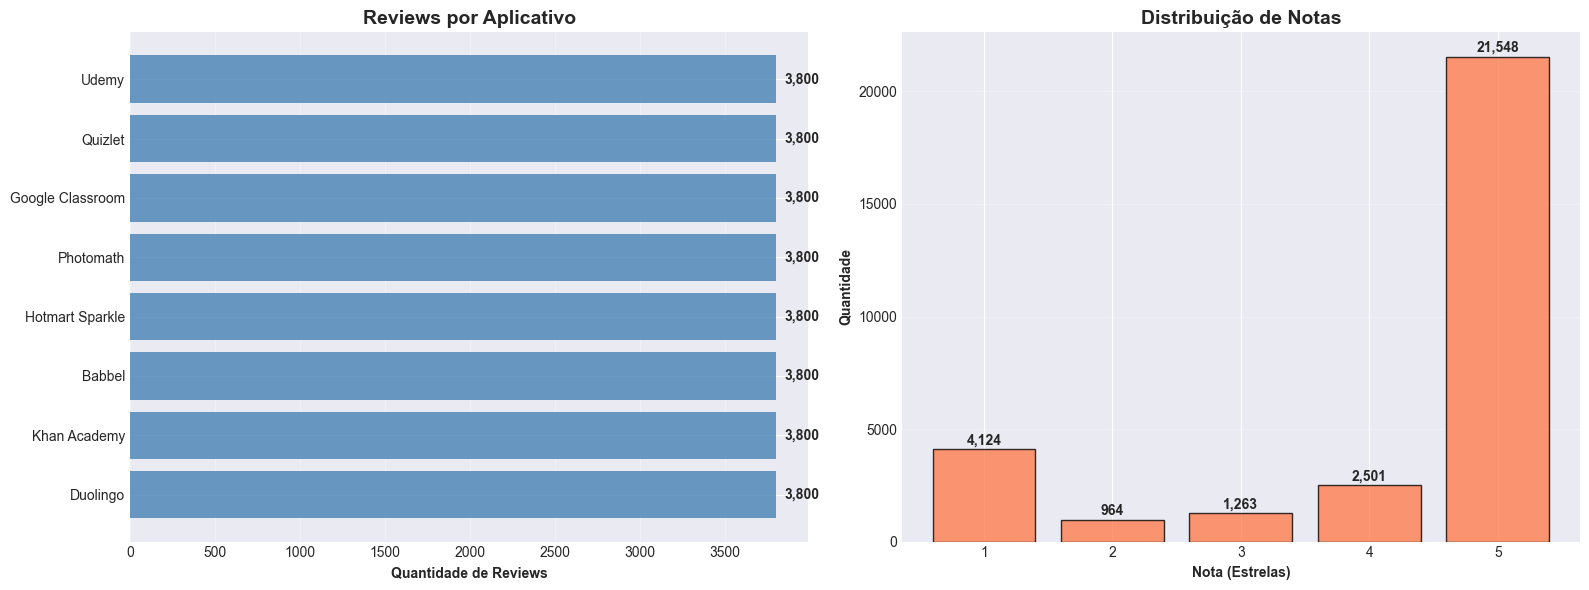

💾 Gráfico salvo: ../results/figures/01_coleta_visao_geral.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Visualização 1: Reviews por App
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Reviews por app
app_counts = df_raw['app'].value_counts().sort_values(ascending=True)
axes[0].barh(app_counts.index, app_counts.values, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Quantidade de Reviews', fontweight='bold')
axes[0].set_title('Reviews por Aplicativo', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(app_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontweight='bold')

# Distribuição de notas
nota_counts = df_raw['nota'].value_counts().sort_index()
axes[1].bar(nota_counts.index, nota_counts.values, color='coral', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Nota (Estrelas)', fontweight='bold')
axes[1].set_ylabel('Quantidade', fontweight='bold')
axes[1].set_title('Distribuição de Notas', fontsize=14, fontweight='bold')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].grid(axis='y', alpha=0.3)
for i, (nota, count) in enumerate(nota_counts.items()):
    axes[1].text(nota, count + 200, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/01_coleta_visao_geral.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Gráfico salvo: ../results/figures/01_coleta_visao_geral.png")

---
## CONCLUSÃO DO NOTEBOOK 1

**O que foi feito:**
- Coletadas ~30.000 reviews de 8 apps educacionais
- Dados salvos em `../data/raw/`
- Visualizações geradas

**Próximo passo:**
➡️ **Notebook 2**: ETL e Análise Exploratória de Dados